# LightGBM 퇴사 예측 모델


## 1. 파일 불러오기 및 라이브러리


In [38]:

from pathlib import Path
import sys

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    average_precision_score,
    ConfusionMatrixDisplay,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold


# data/data_team7.csv 파일이 있는 프로젝트 루트를 찾는 함수
def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start).resolve()
    for path in [start, *start.parents]:
        if (path / "data" / "data_team7.csv").exists():
            return path
    raise FileNotFoundError("data/data_team7.csv was not found.")


PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing_code import get_lgbm_data, load_hr_dataframe

DATA_PATH = PROJECT_ROOT / "data" / "data_team7.csv"
RESULT_DIR = PROJECT_ROOT / "results" / "lgbm_experiments"
RESULT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
USE_FEATURE_ENGINEERING = False

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_PATH:", DATA_PATH)
print("RESULT_DIR:", RESULT_DIR)
print("USE_FEATURE_ENGINEERING:", USE_FEATURE_ENGINEERING)


PROJECT_ROOT: c:\Users\sonju\Documents\과제물, 수업 자료\3학년\3-2\기계학습기초\팀프로젝트\Team-7\Team-7
DATA_PATH: c:\Users\sonju\Documents\과제물, 수업 자료\3학년\3-2\기계학습기초\팀프로젝트\Team-7\Team-7\data\data_team7.csv
RESULT_DIR: c:\Users\sonju\Documents\과제물, 수업 자료\3학년\3-2\기계학습기초\팀프로젝트\Team-7\Team-7\results\lgbm_experiments
USE_FEATURE_ENGINEERING: False


## 2. 데이터, FE 확인


In [39]:
# 원본 데이터와 FE 적용 데이터를 각각 로드
df_base = load_hr_dataframe(DATA_PATH, use_fe=False)
df_fe = load_hr_dataframe(DATA_PATH, use_fe=True)

# 새로 추가된 파생변수만 따로 확인
new_features = sorted(set(df_fe.columns) - set(df_base.columns))

print("데이터 크기:", df_fe.shape)
display(df_fe["Attrition"].value_counts(normalize=True).rename("target_ratio"))
display(pd.DataFrame({"new_feature": new_features}))

데이터 크기: (1470, 43)


Attrition
0    0.838776
1    0.161224
Name: target_ratio, dtype: float64

,new_feature
0,Burnout_Risk
1,Career_Velocity_Index
2,Cost_Effectiveness
3,Income_Per_Level
4,Income_Per_WorkingYear
5,Income_Per_YearAtCompany
6,JobSat_WLB_Interaction
7,Job_Hopping_Index
8,Organizational_Loyalty_Ratio
9,Overwork_Fatigue_Index


## 3. LGBM 데이터 준비


In [41]:

# 데이터 준비
# Feature engineering is off by default because it increased overfitting on this small dataset.

X_train, X_valid, X_test, y_train, y_valid, y_test, feature_names = get_lgbm_data(
    DATA_PATH,
    use_fe=USE_FEATURE_ENGINEERING,
    return_feature_names=True,
)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("X_test:", X_test.shape)
print("target ratio in train:", round(y_train.mean(), 4))


X_train: (1029, 30)
X_valid: (220, 30)
X_test: (221, 30)
target ratio in train: 0.1613


## 4. 평가 함수

In [42]:
 
# f1 기준으로 validation set에서 최적의 threshold 찾기
def find_best_f1_threshold(y_true, y_prob):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)
    f1_scores = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-10)
    best_idx = np.argmax(f1_scores)
    return thresholds[best_idx]

# 분류 모델 평가 함수
def evaluate_binary_model(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return {
        "Threshold": round(float(threshold), 4),
        "Precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "Recall": round(recall_score(y_true, y_pred, zero_division=0), 4),
        "F1": round(f1_score(y_true, y_pred, zero_division=0), 4),
        "ROC-AUC": round(roc_auc_score(y_true, y_prob), 4),
        "PR-AUC": round(average_precision_score(y_true, y_prob), 4),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
    }


## 5. 하이퍼파라미터 튜닝: RandomizedSearchCV, GridSearchCV

pr-auc 기준 RandomizedSearchCV, GridSearchCV로 하이퍼파라미터 튜닝

In [43]:

# Base LGBM model.
# Class imbalance is handled with PR-AUC tuning and a validation threshold.
base_model = lgb.LGBMClassifier(
    objective="binary",
    random_state=RANDOM_STATE,
    n_estimators=120,
    subsample_freq=1,
    n_jobs=1,
    verbose=-1,
)

# Stratified folds keep the attrition ratio stable during CV.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Regularized search space to reduce overfitting.
random_param_grid = {
    "learning_rate": [0.03, 0.05, 0.08],
    "max_depth": [2, 3, 4],
    "num_leaves": [3, 5, 7, 15],
    "min_child_samples": [20, 30, 50, 70],
    "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.7, 0.85, 1.0],
    "reg_alpha": [0, 0.2, 0.5],
    "reg_lambda": [1, 3, 5, 8],
    "min_split_gain": [0, 0.02, 0.05],
}

# GridSearchCV checks a compact set near the regularized candidates.
grid_param_grid = {
    "learning_rate": [0.05, 0.08],
    "max_depth": [2],
    "num_leaves": [3, 5],
    "min_child_samples": [50, 70],
    "subsample": [0.7],
    "colsample_bytree": [0.7, 0.85],
    "reg_alpha": [0.2],
    "reg_lambda": [3, 5],
    "min_split_gain": [0.02],
}

random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=random_param_grid,
    n_iter=35,
    scoring="average_precision",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=1,
)
random_search.fit(X_train, y_train)

grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=grid_param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=1,
)
grid_search.fit(X_train, y_train)

search_summary = pd.DataFrame([
    {"Search": "RandomizedSearchCV", "CV PR-AUC": random_search.best_score_, "Best Params": random_search.best_params_},
    {"Search": "GridSearchCV", "CV PR-AUC": grid_search.best_score_, "Best Params": grid_search.best_params_},
]).sort_values("CV PR-AUC", ascending=False)

search_summary["CV PR-AUC"] = search_summary["CV PR-AUC"].round(4)
display(search_summary)
search_summary.to_csv(RESULT_DIR / "lgbm_search_summary.csv", index=False, encoding="utf-8-sig")


,Search,CV PR-AUC,Best Params
1,GridSearchCV,0.6625,"{'colsample_bytree': 0.7, 'learning_rate': 0.0..."
0,RandomizedSearchCV,0.6622,"{'subsample': 0.7, 'reg_lambda': 5, 'reg_alpha..."


## 6. 최종 모델 학습 및 평가

튜닝 결과 pr-auc 기준 최선의 파라미터 결정, f1 기준으로 threshold 설정, 모델 학습 후 test 성능 확인


In [44]:

# Train and evaluate the final model with the best CV parameters.
if random_search.best_score_ >= grid_search.best_score_:
    best_search_name = "RandomizedSearchCV"
    best_params = random_search.best_params_
else:
    best_search_name = "GridSearchCV"
    best_params = grid_search.best_params_

final_model = lgb.LGBMClassifier(
    objective="binary",
    random_state=RANDOM_STATE,
    n_estimators=500,
    subsample_freq=1,
    n_jobs=1,
    verbose=-1,
    **best_params,
)

# Stop when validation PR-AUC no longer improves.
final_model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_valid, y_valid)],
    eval_names=["train", "valid"],
    eval_metric="average_precision",
    callbacks=[
        lgb.early_stopping(stopping_rounds=30, first_metric_only=True, verbose=False),
        lgb.log_evaluation(period=0),
    ],
)

# Choose the threshold on validation, then evaluate train/validation/test.
train_prob = final_model.predict_proba(X_train)[:, 1]
valid_prob = final_model.predict_proba(X_valid)[:, 1]
best_threshold = find_best_f1_threshold(y_valid, valid_prob)
test_prob = final_model.predict_proba(X_test)[:, 1]

split_results = []
for split_name, y_true, y_prob in [
    ("Train", y_train, train_prob),
    ("Validation", y_valid, valid_prob),
    ("Test", y_test, test_prob),
]:
    result = evaluate_binary_model(y_true, y_prob, best_threshold)
    result["Dataset"] = split_name
    split_results.append(result)

overfit_check_df = pd.DataFrame(split_results)
train_scores = overfit_check_df.loc[overfit_check_df["Dataset"] == "Train"].iloc[0]
overfit_check_df["PR-AUC Gap vs Train"] = (train_scores["PR-AUC"] - overfit_check_df["PR-AUC"]).round(4)
overfit_check_df["F1 Gap vs Train"] = (train_scores["F1"] - overfit_check_df["F1"]).round(4)
overfit_check_df["Best Search"] = best_search_name
overfit_check_df["Best Iteration"] = final_model.best_iteration_
overfit_check_df["Best Params"] = str(best_params)

display(overfit_check_df)
overfit_check_df.to_csv(RESULT_DIR / "lgbm_test_result.csv", index=False, encoding="utf-8-sig")


,Threshold,Precision,Recall,F1,ROC-AUC,PR-AUC,TN,FP,FN,TP,Dataset,PR-AUC Gap vs Train,F1 Gap vs Train,Best Search,Best Iteration,Best Params
0,0.1999,0.5607,0.8072,0.6617,0.9218,0.8261,758,105,32,134,Train,0.0000,0.0000,GridSearchCV,180,"{'colsample_bytree': 0.7, 'learning_rate': 0.0..."
1,0.1999,0.4561,0.7429,0.5652,0.7747,0.4715,154,31,9,26,Validation,0.3546,0.0965,GridSearchCV,180,"{'colsample_bytree': 0.7, 'learning_rate': 0.0..."
2,0.1999,0.4364,0.6667,0.5275,0.8347,0.5672,154,31,12,24,Test,0.2589,0.1342,GridSearchCV,180,"{'colsample_bytree': 0.7, 'learning_rate': 0.0..."


## 7. 시각화 저장

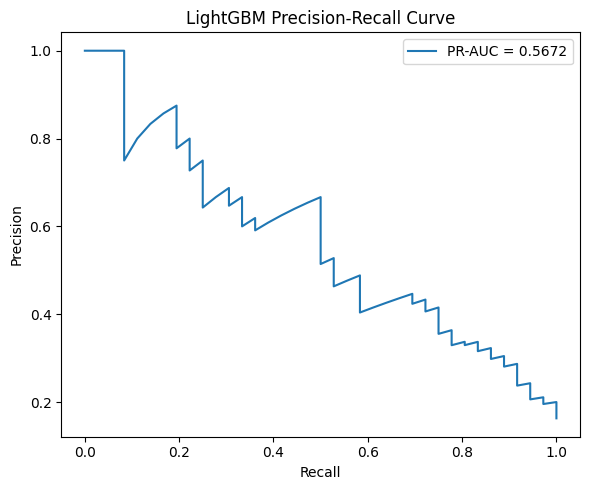

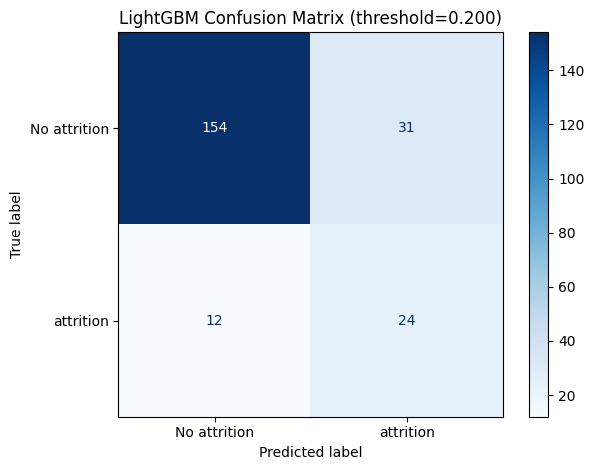

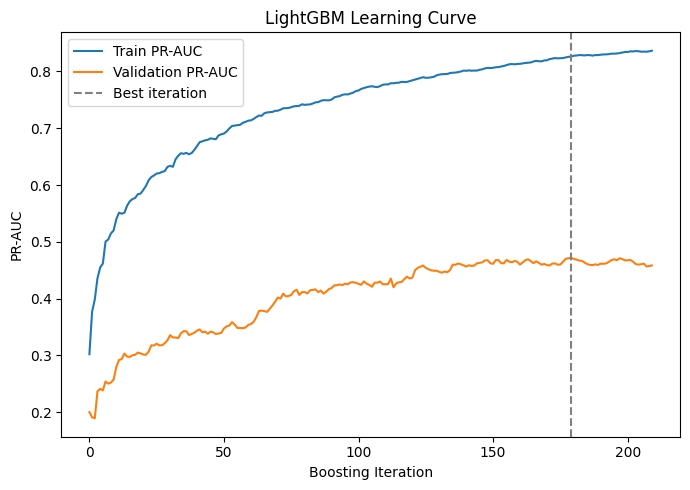

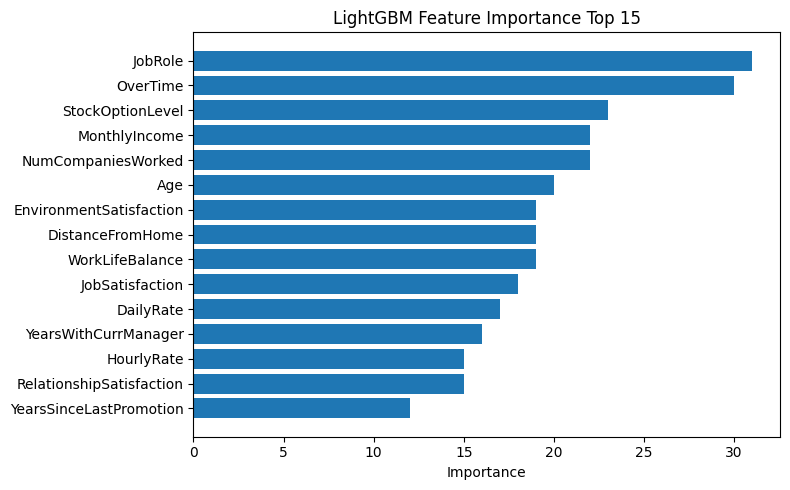

Saved to: c:\Users\sonju\Documents\과제물, 수업 자료\3학년\3-2\기계학습기초\팀프로젝트\Team-7\Team-7\results\lgbm_experiments


In [ ]:

# pr-auc
precisions, recalls, _ = precision_recall_curve(y_test, test_prob)
test_pr_auc = average_precision_score(y_test, test_prob)

plt.figure(figsize=(6, 5))
plt.plot(recalls, precisions, label=f"PR-AUC = {test_pr_auc:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("LightGBM Precision-Recall Curve")
plt.legend()
plt.tight_layout()
plt.savefig(RESULT_DIR / "lgbm_pr_curve.png", dpi=150)
plt.show()

# 혼동 행렬
test_pred = (test_prob >= best_threshold).astype(int)
cm = confusion_matrix(y_test, test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No attrition", "attrition"])
disp.plot(cmap="Blues", values_format="d")
plt.title(f"LightGBM Confusion Matrix (threshold={best_threshold:.3f})")
plt.tight_layout()
plt.savefig(RESULT_DIR / "lgbm_confusion_matrix.png", dpi=150)
plt.show()

# Train/validation PR-AUC by boosting iteration.
eval_result = final_model.evals_result_
train_pr_auc = eval_result["train"]["average_precision"]
valid_pr_auc = eval_result["valid"]["average_precision"]

plt.figure(figsize=(7, 5))
plt.plot(train_pr_auc, label="Train PR-AUC")
plt.plot(valid_pr_auc, label="Validation PR-AUC")
plt.axvline(final_model.best_iteration_ - 1, color="gray", linestyle="--", label="Best iteration")
plt.xlabel("Boosting Iteration")
plt.ylabel("PR-AUC")
plt.title("LightGBM Learning Curve")
plt.legend()
plt.tight_layout()
plt.savefig(RESULT_DIR / "lgbm_learning_curve.png", dpi=150)
plt.show()

# Top 15 feature importances.
importance = pd.DataFrame({
    "feature": feature_names,
    "importance": final_model.feature_importances_,
}).sort_values("importance", ascending=False)

top15 = importance.head(15).sort_values("importance")
plt.figure(figsize=(8, 5))
plt.barh(top15["feature"], top15["importance"])
plt.xlabel("Importance")
plt.title("LightGBM Feature Importance Top 15")
plt.tight_layout()
plt.savefig(RESULT_DIR / "lgbm_feature_importance.png", dpi=150)
plt.show()

importance.to_csv(RESULT_DIR / "lgbm_feature_importance.csv", index=False, encoding="utf-8-sig")
print("Saved to:", RESULT_DIR)
